# SPX Options — Implied Volatility & Variance Risk Premium
### Econometrics Project · Politecnico di Milano

**Research questions**
1. Does implied volatility predict realized volatility? *(linear regression)*
2. Does the skew add incremental predictive power? *(multivariate regression)*
3. Is there a persistent Variance Risk Premium? *(VRP = IV − RV)*

**Dataset** · One-year S&P 500 options (08 Jun 2017 → 08 Jun 2018)  
**Methods covered** · OLS, Fixed Effects, ARMA, VAR, GARCH, Cointegration, PCA

---


## 0 · Imports & configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import brentq
import warnings, os, glob
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_white
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})

# ── User settings ──────────────────────────────────────────────────────────────
DATA_FOLDER   = './data'        # folder containing all YYYY-MM-DD.csv files
RISK_FREE     = 0.02            # constant risk-free rate (US 1Y T-bill ~2% in 2017-18)
TARGET_TENOR  = 30              # target tenor in days for daily metrics
WING_LOW      = -0.15           # put-wing lower bound (log-moneyness)
WING_HIGH_PUT = -0.05           # put-wing upper bound
WING_LOW_CALL =  0.05           # call-wing lower bound
WING_HIGH     =  0.15           # call-wing upper bound
RV_WINDOW     = 21              # rolling window for realized vol (trading days)

print("Libraries loaded")

Libraries loaded


## 1 · Black-Scholes pricing & implied volatility

### 1.1 Theoretical background

The **Black-Scholes** formula prices a European option under the assumptions of:
- Log-normal dynamics for the underlying: $dS = \mu S\,dt + \sigma S\,dW_t$
- Constant volatility $\sigma$, constant risk-free rate $r$, no dividends

$$C(S,K,T,r,\sigma) = S\,\Phi(d_1) - K e^{-rT}\,\Phi(d_2)$$

$$d_1 = \frac{\ln(S/K) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

**Implied volatility** $\hat\sigma$ is the value of $\sigma$ that equates the model price to the observed market price:

$$\hat\sigma = \{\sigma : \text{BS}(S,K,T,r,\sigma) = C^{\text{mkt}}\}$$

We solve this numerically using **Brent's method** (bracketed root-finding, guaranteed convergence).


In [2]:
def bs_price(S, K, T, r, sigma, opt_type='C'):
    """Black-Scholes option price."""
    if T <= 0 or sigma <= 0:
        return np.nan
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if opt_type == 'C':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


def implied_vol(mkt_price, S, K, T, r, opt_type='C'):
    """
    Implied volatility via Brent's method.
    Returns NaN when no-arbitrage bounds are violated or root not found.
    """
    if T <= 0 or mkt_price <= 0:
        return np.nan
    intrinsic = max(S - K, 0) if opt_type == 'C' else max(K - S, 0)
    if mkt_price < intrinsic * 0.999:
        return np.nan
    if opt_type == 'C' and mkt_price >= S:
        return np.nan
    try:
        return brentq(
            lambda s: bs_price(S, K, T, r, s, opt_type) - mkt_price,
            1e-6, 10.0, xtol=1e-6, maxiter=200
        )
    except (ValueError, RuntimeError):
        return np.nan


# ── Quick sanity check ─────────────────────────────────────────────────────────
S_test, K_test, T_test, r_test, sig_test = 100, 100, 0.25, 0.02, 0.20
price_test = bs_price(S_test, K_test, T_test, r_test, sig_test, 'C')
iv_back    = implied_vol(price_test, S_test, K_test, T_test, r_test, 'C')
print(f"BS price (ATM call, σ=20%): {price_test:.4f}")
print(f"Recovered IV:               {iv_back*100:.4f}%  ← should be 20.0000%")
assert abs(iv_back - sig_test) < 1e-5, "IV inversion failed!"
print("Black-Scholes & IV inversion validated")


BS price (ATM call, σ=20%): 4.2322
Recovered IV:               20.0000%  ← should be 20.0000%
Black-Scholes & IV inversion validated


## 2 · Data loading & cleaning

### 2.1 Dataset description

Each daily file contains all listed SPX options for that trading day.  
Columns: `date`, `ask`, `bid`, `strike`, `open_interest`, `exp_date`, `type (C/P)`.

The dataset spans **10 expiry dates** (7d to 924d) with ~150 strikes each → ~1,500 rows/day.

### 2.2 Cleaning steps
1. Parse dates, compute $T = (\text{expiry} - \text{date}) / 365$
2. Compute mid price: $P^{\text{mid}} = (\text{ask} + \text{bid}) / 2$
3. Drop options with $T < 7$ days (expiry micro-structure noise)
4. Drop options with relative bid-ask spread $> 50\%$ (illiquid)
5. Estimate spot $S$ via **put-call parity**: $C - P = S - Ke^{-rT}$


In [5]:
def load_and_clean(data_folder):
    """Load all daily CSVs, clean, and estimate spot via put-call parity."""
    files = sorted(glob.glob(os.path.join(data_folder, '*.csv')))
    if not files:
        raise FileNotFoundError(f"No CSV files in {data_folder!r}")
    print(f"Loading {len(files)} files...")

    dfs = []
    for f in files:
        try:
            dfs.append(pd.read_csv(f))
        except Exception as e:
            print(f"  ⚠ {f}: {e}")

    df = pd.concat(dfs, ignore_index=True)
    df.columns = ['date','date2','ask','bid','strike','oi',
                  'strike2','high','low','open','instrument','exp_date','type']

    df['date']     = pd.to_datetime(df['date'])
    df['exp_date'] = pd.to_datetime(df['exp_date'])
    df['T']        = (df['exp_date'] - df['date']).dt.days / 365.0
    df['mid']      = (df['ask'] + df['bid']) / 2.0

    # Drop expiry noise & illiquid options
    df = df[df['T'] > 7/365].copy()
    df = df[df['mid'] > 0].copy()
    df['ba_rel'] = (df['ask'] - df['bid']) / df['mid']
    df = df[df['ba_rel'] < 0.5].copy()

    # ── Estimate spot S via put-call parity, per (date, exp_date) ──────────────
    calls = df[df['type']=='C'][['date','exp_date','strike','T','mid']].rename(columns={'mid':'C'})
    puts  = df[df['type']=='P'][['date','exp_date','strike','T','mid']].rename(columns={'mid':'P'})
    pairs = pd.merge(calls, puts, on=['date','exp_date','strike','T'])
    pairs['G'] = pairs['C'] - pairs['P']

    spot_rows = []
    for (date, exp), grp in pairs.groupby(['date', 'exp_date']):
        if len(grp) < 3:   # need enough strikes for a reliable regression
            continue
        coef = np.polyfit(grp['strike'], grp['G'], deg=1)
        B = -coef[0]                    # slope = -B
        if B <= 0:                      # discard degenerate cases
            continue
        F = coef[1] / B                 # intercept = B*F  →  F = intercept/B
        S_est = F * B                   # S = F * B  (= F * e^{-rT})
        spot_rows.append({'date': date, 'exp_date': exp, 'S_est': S_est})

    spot_df = pd.DataFrame(spot_rows)

    # One spot per day: median across expiries
    spot_per_date = spot_df.groupby('date')['S_est'].median().rename('spot')

    df = df.merge(spot_per_date, on='date')
    df['log_m'] = np.log(df['strike'] / df['spot'])

    print(f"✓ Rows after cleaning : {len(df):,}")
    print(f"  Trading days        : {df['date'].nunique()}")
    print(f"  Unique expiries     : {df['exp_date'].nunique()}")
    print(f"  Spot range          : {df['spot'].min():.0f} – {df['spot'].max():.0f}")
    return df


# ── Run ─────────────────────────────────────────────────────────────────────────
df_raw = load_and_clean(DATA_FOLDER)
df_raw.head(3)


Loading 253 files...
✓ Rows after cleaning : 355,202
  Trading days        : 253
  Unique expiries     : 22
  Spot range          : 2387 – 2839


,date,date2,ask,bid,strike,oi,strike2,high,low,open,instrument,exp_date,type,T,mid,ba_rel,spot,log_m
0,2017-06-08,2017-06-08,1326.4,1306.7,1100.0,400.0,1100,1316.55,1316.55,1316.55,SPX01181100C,2018-01-19,C,0.616438,1316.55,0.014963,2408.002083,-0.783487
1,2017-06-08,2017-06-08,1301.7,1282.0,1125.0,0.0,1125,1291.85,1291.85,1291.85,SPX01181125C,2018-01-19,C,0.616438,1291.85,0.015249,2408.002083,-0.761014
2,2017-06-08,2017-06-08,1277.0,1257.3,1150.0,0.0,1150,1267.15,1267.15,1267.15,SPX01181150C,2018-01-19,C,0.616438,1267.15,0.015547,2408.002083,-0.739035


## 3 · IV surface computation

We compute the IV for every option row.  
**Note**: for deep ITM options the BS formula becomes ill-conditioned (very high vega sensitivity).  
We restrict to $\log(K/S) \in [-0.6,\, 0.4]$ and discard IVs outside $[1\%,\, 200\%]$.

This is the most computationally intensive step (~5-10 min for the full year).  
Progress is printed every 10,000 rows.


In [7]:
def compute_iv_surface(df):
    """Vectorised IV computation with progress reporting."""
    # Pre-filter to a sensible moneyness range (speeds up & improves quality)
    df = df[(df['log_m'] > -0.6) & (df['log_m'] < 0.4)].copy()
    print(f"Computing IV for {len(df):,} options...")

    ivs = np.full(len(df), np.nan)
    for i, (_, row) in enumerate(df.iterrows()):
        ivs[i] = implied_vol(row['mid'], row['spot'], row['strike'],
                             row['T'], RISK_FREE, row['type'])
        if (i + 1) % 10_000 == 0:
            pct = (i + 1) / len(df) * 100
            valid = np.sum(~np.isnan(ivs[:i+1]))
            print(f"  {i+1:>6,} / {len(df):,}  ({pct:.0f}%)  valid IV: {valid:,}")

    df['iv'] = ivs
    df = df[(df['iv'] > 0.01) & (df['iv'] < 2.0)].copy()
    print(f"✓ Valid IVs: {len(df):,}")
    return df


df = compute_iv_surface(df_raw)
# Optional: cache to disk to avoid recomputing
# df.to_parquet('iv_surface.parquet', index=False)
df.head(3)


Computing IV for 323,900 options...
  10,000 / 323,900  (3%)  valid IV: 8,027
  20,000 / 323,900  (6%)  valid IV: 15,945
  30,000 / 323,900  (9%)  valid IV: 23,886
  40,000 / 323,900  (12%)  valid IV: 31,766
  50,000 / 323,900  (15%)  valid IV: 39,596
  60,000 / 323,900  (19%)  valid IV: 47,508
  70,000 / 323,900  (22%)  valid IV: 55,409
  80,000 / 323,900  (25%)  valid IV: 63,440
  90,000 / 323,900  (28%)  valid IV: 71,630
  100,000 / 323,900  (31%)  valid IV: 79,786
  110,000 / 323,900  (34%)  valid IV: 88,075
  120,000 / 323,900  (37%)  valid IV: 96,255
  130,000 / 323,900  (40%)  valid IV: 104,550
  140,000 / 323,900  (43%)  valid IV: 112,862
  150,000 / 323,900  (46%)  valid IV: 121,318
  160,000 / 323,900  (49%)  valid IV: 129,898
  170,000 / 323,900  (52%)  valid IV: 138,483
  180,000 / 323,900  (56%)  valid IV: 147,228
  190,000 / 323,900  (59%)  valid IV: 155,955
  200,000 / 323,900  (62%)  valid IV: 164,494
  210,000 / 323,900  (65%)  valid IV: 173,019
  220,000 / 323,900  (6

,date,date2,ask,bid,strike,oi,strike2,high,low,open,instrument,exp_date,type,T,mid,ba_rel,spot,log_m,iv
14,2017-06-08,2017-06-08,3.2,2.3,1500.0,3396.0,1500,2.75,2.75,2.75,SPX01181500P,2018-01-19,P,0.616438,2.75,0.327273,2408.002083,-0.473332,0.293616
18,2017-06-08,2017-06-08,4.4,3.2,1575.0,460.0,1575,3.80,3.80,3.80,SPX01181575P,2018-01-19,P,0.616438,3.80,0.315789,2408.002083,-0.424542,0.280944
20,2017-06-08,2017-06-08,4.8,3.6,1600.0,2164.0,1600,4.20,4.20,4.20,SPX01181600P,2018-01-19,P,0.616438,4.20,0.285714,2408.002083,-0.408794,0.276510


## 4 · Volatility smile & surface

### 4.1 The smile

Under Black-Scholes, IV should be **constant** across strikes.  
In practice it is not — OTM puts are more expensive (higher IV) than OTM calls:
- Investors pay an **insurance premium** against left-tail crashes
- This creates the characteristic left-skewed smile observed for equity indices

### 4.2 Metrics

| Metric | Definition | Interpretation |
|---|---|---|
| **ATM IV** | IV at $\log(K/S) \approx 0$ | Overall level of market fear |
| **Skew** | IV(put wing) − IV(call wing) | Asymmetry / demand for downside protection |
| **Convexity** | $\frac{IV_{put} + IV_{call}}{2} - IV_{ATM}$ | Curvature of the smile ("wings") |


Plotting smile for 2018-06-08  expiry=2018-07-20  T=42d


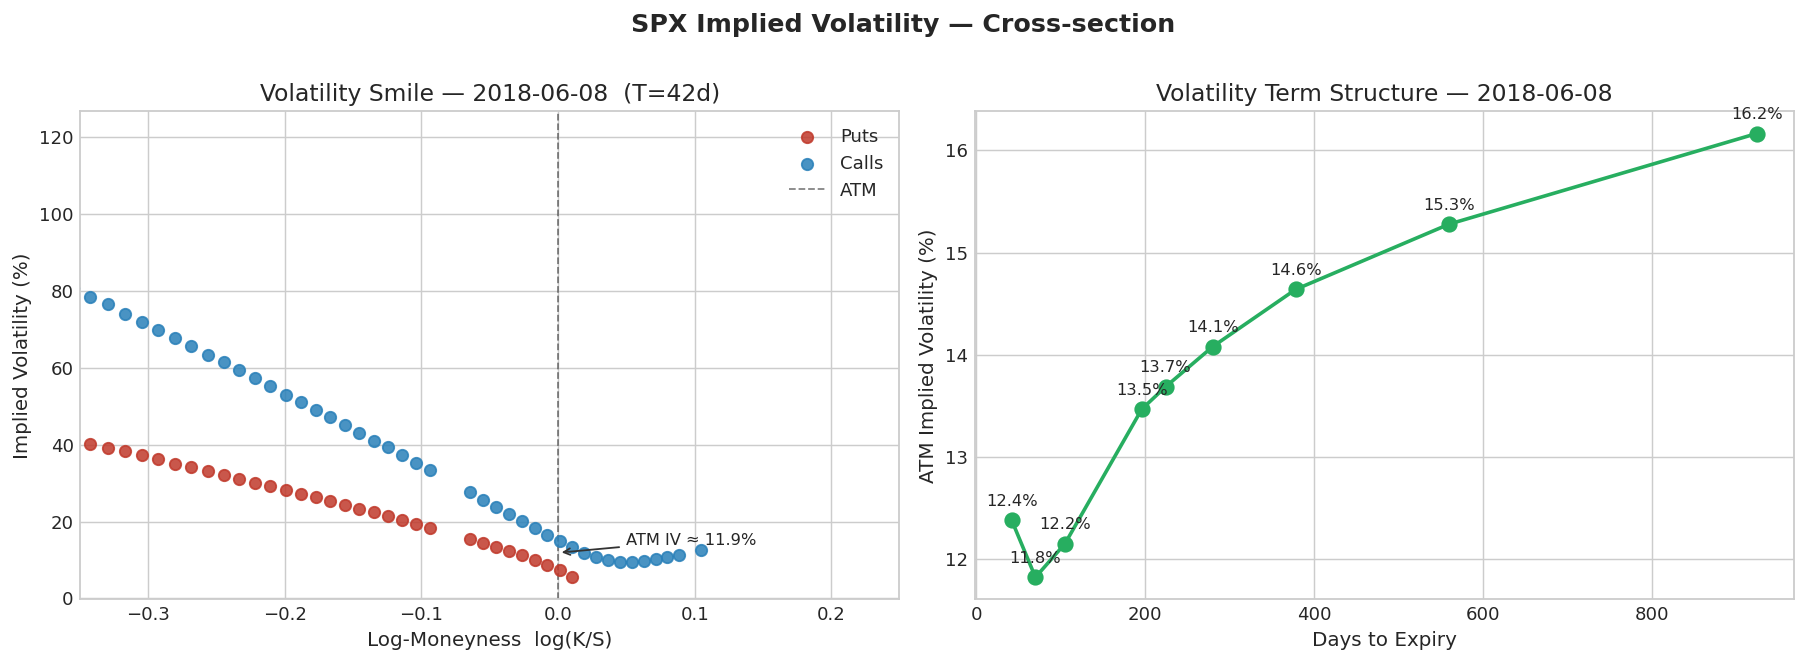

In [8]:
# ── Pick one representative date ──────────────────────────────────────────────
sample_date = pd.Timestamp('2018-06-08')   # change as needed
day_df = df[df['date'] == sample_date]

# Best expiry ~ TARGET_TENOR days
exp_options = day_df['exp_date'].unique()
best_exp    = exp_options[
    np.argmin(np.abs((pd.to_datetime(exp_options) - sample_date).days - TARGET_TENOR))
]
smile_df = day_df[day_df['exp_date'] == best_exp].sort_values('log_m')
T_actual = int((best_exp - sample_date).days)
print(f"Plotting smile for {sample_date.date()}  expiry={best_exp.date()}  T={T_actual}d")

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Smile
ax = axes[0]
for opt_type, color, label in [('P','#c0392b','Puts'), ('C','#2980b9','Calls')]:
    sub = smile_df[smile_df['type'] == opt_type]
    ax.scatter(sub['log_m'], sub['iv']*100, color=color, s=40, alpha=0.85,
               label=label, zorder=3)
ax.axvline(0, color='#333', lw=1, ls='--', alpha=0.6, label='ATM')
atm_iv_val = smile_df[smile_df['log_m'].abs() < 0.01]['iv'].mean() * 100
ax.annotate(f'ATM IV ≈ {atm_iv_val:.1f}%', xy=(0, atm_iv_val),
            xytext=(0.05, atm_iv_val + 2), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#333', lw=1))
ax.set(xlabel='Log-Moneyness  log(K/S)', ylabel='Implied Volatility (%)',
       title=f'Volatility Smile — {sample_date.date()}  (T={T_actual}d)',
       xlim=(-0.35, 0.25))
ax.legend(fontsize=10)

# Right: Term structure of ATM IV
ts_rows = []
for exp in sorted(day_df['exp_date'].unique()):
    sub = day_df[(day_df['exp_date'] == exp) & (day_df['log_m'].abs() < 0.03)]
    if len(sub) > 0:
        ts_rows.append({'days': (exp - sample_date).days, 'atm_iv': sub['iv'].mean()*100})
ts = pd.DataFrame(ts_rows)
ax = axes[1]
ax.plot(ts['days'], ts['atm_iv'], 'o-', color='#27ae60', lw=2, ms=8)
for _, r in ts.iterrows():
    ax.annotate(f"{r['atm_iv']:.1f}%", (r['days'], r['atm_iv']),
                textcoords='offset points', xytext=(0, 8), fontsize=9, ha='center')
ax.set(xlabel='Days to Expiry', ylabel='ATM Implied Volatility (%)',
       title=f'Volatility Term Structure — {sample_date.date()}')

plt.suptitle('SPX Implied Volatility — Cross-section', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_smile_termstructure.png', dpi=150, bbox_inches='tight')
plt.show()


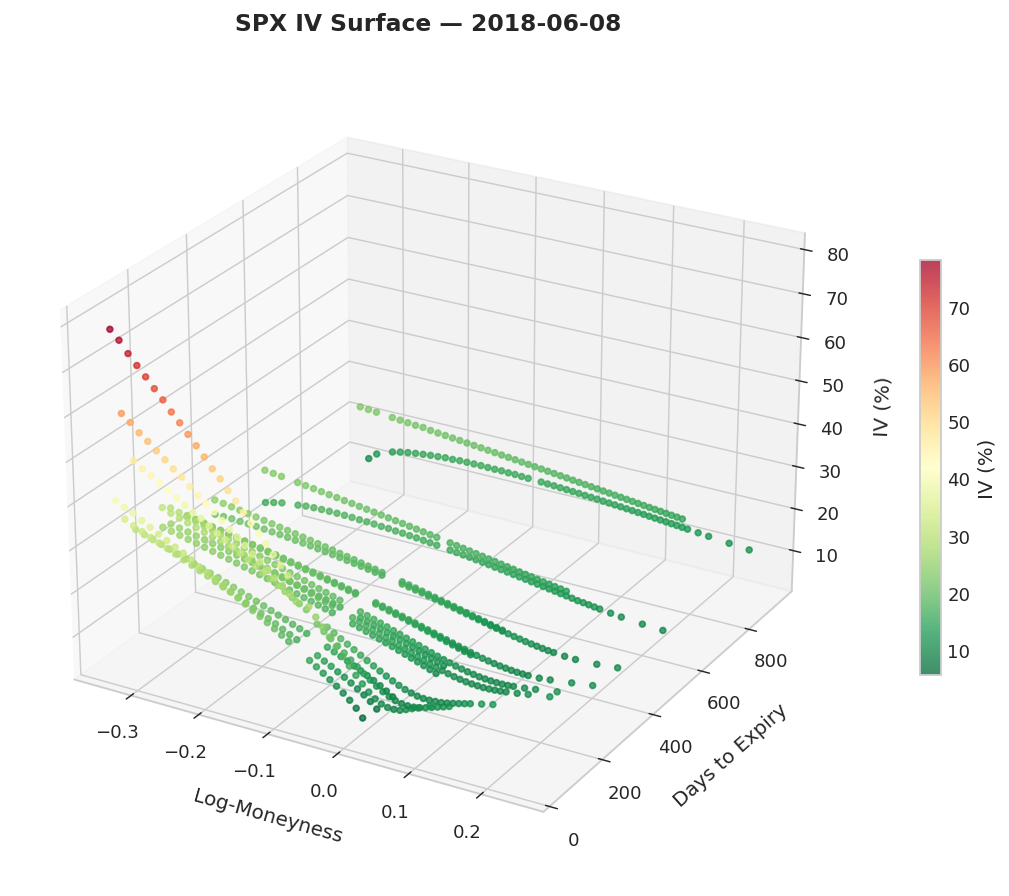

In [9]:
# ── 3-D volatility surface ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection='3d')
surf_df = day_df[(day_df['log_m'] > -0.35) & (day_df['log_m'] < 0.25)]
sc = ax.scatter(surf_df['log_m'], surf_df['T']*365, surf_df['iv']*100,
                c=surf_df['iv']*100, cmap='RdYlGn_r', s=10, alpha=0.75)
ax.set_xlabel('Log-Moneyness', labelpad=8)
ax.set_ylabel('Days to Expiry', labelpad=8)
ax.set_zlabel('IV (%)', labelpad=8)
ax.set_title(f'SPX IV Surface — {sample_date.date()}', fontweight='bold', pad=12)
plt.colorbar(sc, ax=ax, shrink=0.5, label='IV (%)')
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.savefig('fig2_vol_surface.png', dpi=150, bbox_inches='tight')
plt.show()


## 5 · Daily time-series: ATM IV (constant maturity), skew, convexity

### 5.1 The varying-tenor problem

A naive approach would select, each day, the expiry closest to the target tenor (30 days). This produces a **heterogeneous** $X_t$: the selected option may have 42 days to expiry one day and 20 days the next, with discrete jumps each time a new expiry becomes the nearest. Within a single expiry cycle the tenor drifts continuously downward, then jumps abruptly at each roll. Comparing a 42-day IV one day to a 20-day IV the next breaks the consistency of the regressor series $X_t$.



### 5.2 Solution: constant-maturity interpolation

We bracket the target tenor $\tau = 30$ days between the two available expiries $T_1 \leq \tau < T_2$ and interpolate **in variance** (linearly in $\sigma^2$, not in $\sigma$):

$$\sigma_{\tau}^2 = \frac{T_2 - \tau}{T_2 - T_1}\,\sigma_{T_1}^2 + \frac{\tau - T_1}{T_2 - T_1}\,\sigma_{T_2}^2$$

$$\sigma_{\tau} = \sqrt{\sigma_{\tau}^2}$$

Interpolation is performed in variance rather than volatility because variance is additive in time under Black-Scholes: $\sigma^2 T$ represents the expected integrated variance, and it is this quantity that scales linearly with $T$. This is exactly the methodology used by the **CBOE to compute the VIX**.

### 5.3 Extracted metrics

The same three metrics are computed for each of the two bracketing expiries and then interpolated separately:

$$\text{Skew}_t = \overline{\text{IV}}_{\text{put wing}} - \overline{\text{IV}}_{\text{call wing}}$$

$$\text{Convexity}_t = \frac{\overline{\text{IV}}_{\text{put wing}} + \overline{\text{IV}}_{\text{call wing}}}{2} - \text{ATM\_IV}_t$$

In [10]:
def _slice_metrics(t_df, wing_lo, wing_hi_p, wing_lo_c, wing_hi):
    """ATM IV, put-wing IV, call-wing IV for a single expiry slice."""
    if len(t_df) < 3:
        return np.nan, np.nan, np.nan
    atm_iv = t_df.loc[t_df['log_m'].abs().idxmin(), 'iv']
    p_wing = t_df[(t_df['log_m'] > wing_lo)  & (t_df['log_m'] < wing_hi_p) & (t_df['type']=='P')]
    c_wing = t_df[(t_df['log_m'] > wing_lo_c) & (t_df['log_m'] < wing_hi)  & (t_df['type']=='C')]
    iv_p   = p_wing['iv'].mean() if len(p_wing) > 0 else np.nan
    iv_c   = c_wing['iv'].mean() if len(c_wing) > 0 else np.nan
    return atm_iv, iv_p, iv_c


def _interp_var(iv1, iv2, T1, T2, tau):
    """Linear interpolation in variance space between tenors T1 < tau <= T2."""
    if T1 == T2:
        return iv1
    w1  = (T2 - tau) / (T2 - T1)
    w2  = (tau - T1) / (T2 - T1)
    var = w1 * iv1**2 + w2 * iv2**2
    return np.sqrt(max(var, 0.0))


def extract_daily_metrics(df, target_tenor=TARGET_TENOR,
                          wing_lo=WING_LOW, wing_hi_p=WING_HIGH_PUT,
                          wing_lo_c=WING_LOW_CALL, wing_hi=WING_HIGH):
    """
    Extract ATM IV, skew, convexity per trading day using constant-maturity
    interpolation: variance-weighted blend of the two expiries bracketing
    target_tenor days (same methodology as the CBOE VIX).
    """
    rows = []
    for date, day in df.groupby('date'):
        exps   = np.array(sorted(day['exp_date'].unique()))
        tenors = np.array([(pd.Timestamp(e) - date).days for e in exps])

        below = tenors[tenors <= target_tenor]
        above = tenors[tenors >  target_tenor]

        if len(below) == 0 or len(above) == 0:
            # Edge case: target is outside available range → use closest expiry
            best_exp = exps[np.argmin(np.abs(tenors - target_tenor))]
            t_df     = day[day['exp_date'] == best_exp].sort_values('log_m')
            atm_iv, iv_p, iv_c = _slice_metrics(t_df, wing_lo, wing_hi_p, wing_lo_c, wing_hi)
        else:
            T1   = int(below[-1])   # largest tenor <= target
            T2   = int(above[0])    # smallest tenor > target
            exp1 = exps[tenors == T1][0]
            exp2 = exps[tenors == T2][0]

            t_df1 = day[day['exp_date'] == exp1].sort_values('log_m')
            t_df2 = day[day['exp_date'] == exp2].sort_values('log_m')

            atm1, ivp1, ivc1 = _slice_metrics(t_df1, wing_lo, wing_hi_p, wing_lo_c, wing_hi)
            atm2, ivp2, ivc2 = _slice_metrics(t_df2, wing_lo, wing_hi_p, wing_lo_c, wing_hi)

            if np.isnan(atm1) or np.isnan(atm2):
                atm_iv = atm1 if not np.isnan(atm1) else atm2
                iv_p   = ivp1 if not np.isnan(ivp1) else ivp2
                iv_c   = ivc1 if not np.isnan(ivc1) else ivc2
            else:
                atm_iv = _interp_var(atm1, atm2, T1, T2, target_tenor)
                iv_p   = _interp_var(ivp1, ivp2, T1, T2, target_tenor) \
                         if not (np.isnan(ivp1) or np.isnan(ivp2)) else np.nan
                iv_c   = _interp_var(ivc1, ivc2, T1, T2, target_tenor) \
                         if not (np.isnan(ivc1) or np.isnan(ivc2)) else np.nan

        rows.append({
            'date'        : date,
            'atm_iv'      : atm_iv,
            'skew'        : iv_p - iv_c if not (np.isnan(iv_p) or np.isnan(iv_c)) else np.nan,
            'convexity'   : (iv_p + iv_c) / 2 - atm_iv
                            if not (np.isnan(iv_p) or np.isnan(iv_c)) else np.nan,
            'iv_put_wing' : iv_p,
            'iv_call_wing': iv_c,
        })

    metrics = pd.DataFrame(rows).set_index('date').sort_index()
    print(f"✓ Daily metrics: {len(metrics)} trading days  "
          f"(constant-maturity {target_tenor}d interpolation)")
    return metrics


metrics = extract_daily_metrics(df)
metrics.head()


✓ Daily metrics: 253 trading days  (constant-maturity 30d interpolation)


,atm_iv,skew,convexity,iv_put_wing,iv_call_wing
date,,,,,
2017-06-08,0.170958,NaN,NaN,0.222966,NaN
2017-06-09,0.137690,NaN,NaN,0.180820,NaN
2017-06-12,0.142337,0.087259,0.002463,0.188429,0.101170
2017-06-13,0.124111,0.081604,0.017452,0.182365,0.100762
2017-06-14,0.145607,0.072546,0.000264,0.182145,0.109599


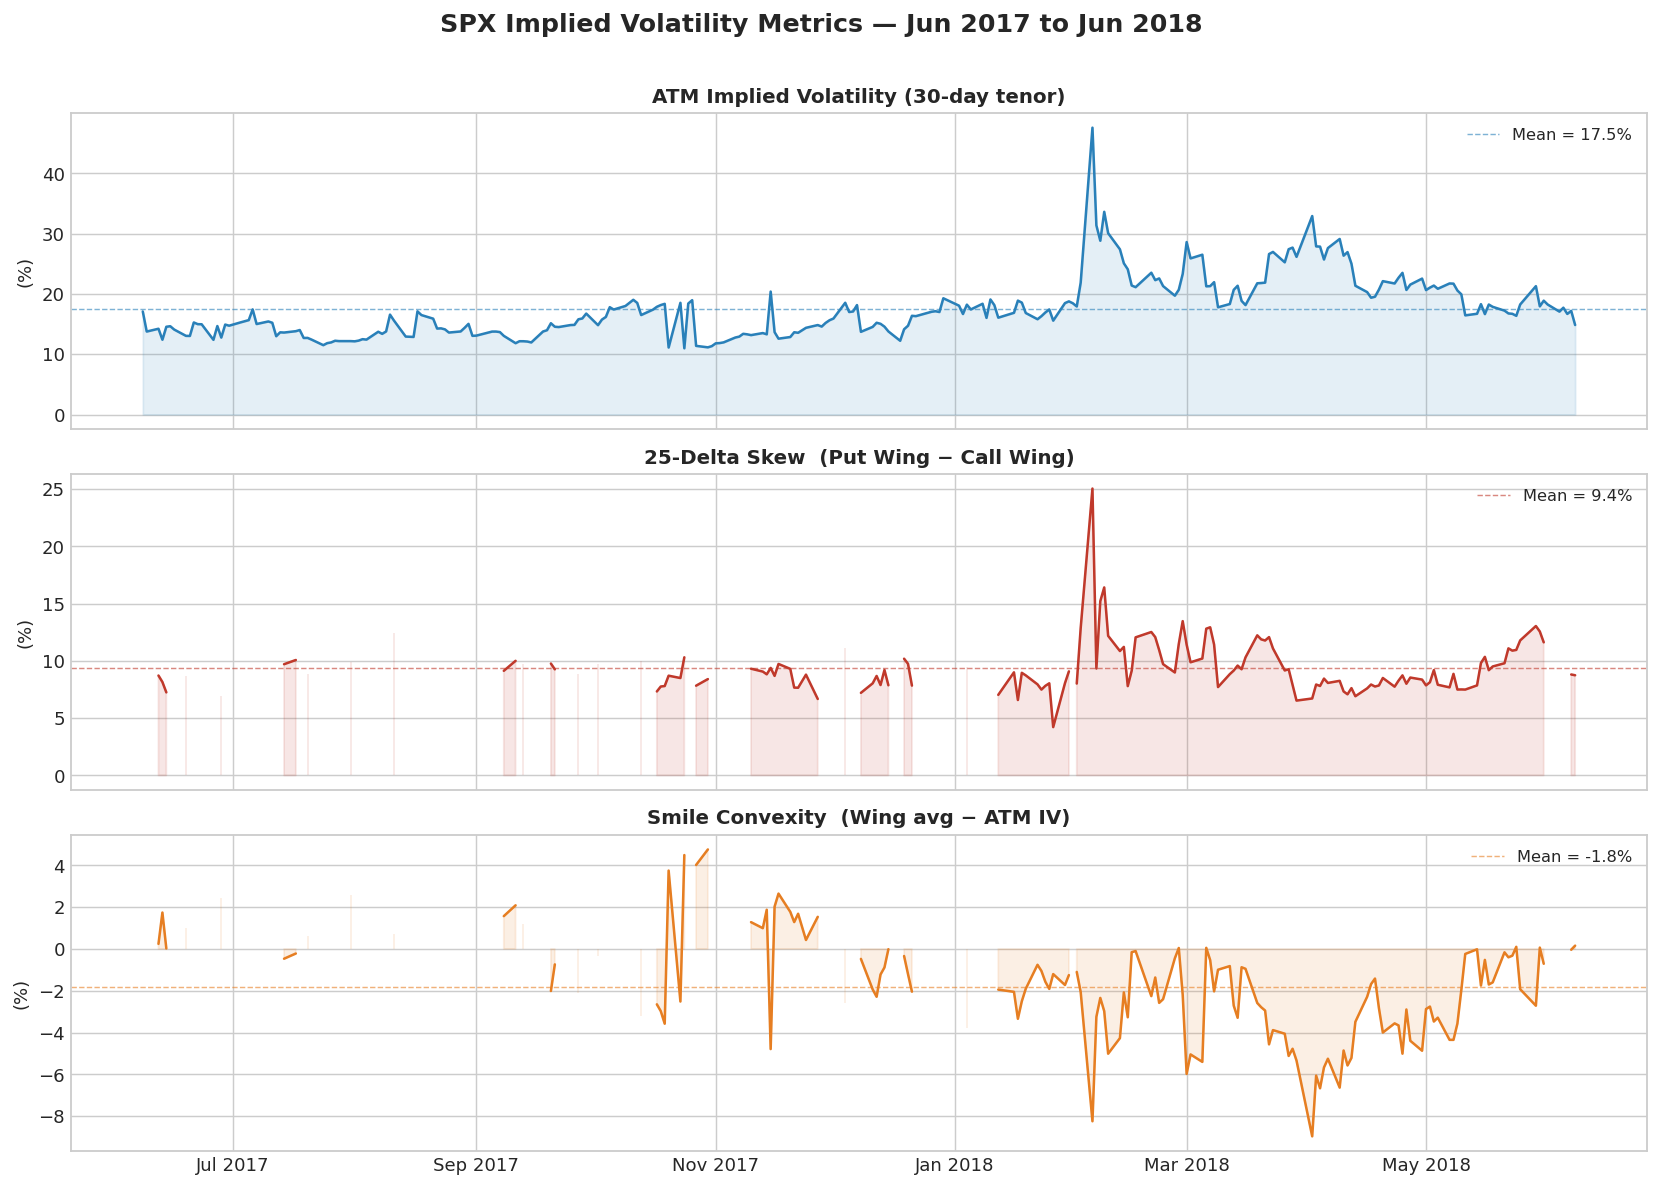

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
colors = ['#2980b9', '#c0392b', '#e67e22']
titles = ['ATM Implied Volatility (30-day tenor)',
          '25-Delta Skew  (Put Wing − Call Wing)',
          'Smile Convexity  (Wing avg − ATM IV)']
cols   = ['atm_iv', 'skew', 'convexity']

for ax, col, color, title in zip(axes, cols, colors, titles):
    y = metrics[col] * 100
    ax.plot(metrics.index, y, color=color, lw=1.4)
    ax.fill_between(metrics.index, y, alpha=0.12, color=color)
    ax.axhline(y.mean(), color=color, lw=0.8, ls='--', alpha=0.6,
               label=f'Mean = {y.mean():.1f}%')
    ax.set_ylabel('(%)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('SPX Implied Volatility Metrics — Jun 2017 to Jun 2018',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_iv_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


## 6 · Realized volatility & Variance Risk Premium

**Realized volatility** (historical) over a rolling 21-day window:

$$RV_t = \sqrt{252} \cdot \hat\sigma\left(r_{t-20},\ldots,r_{t}\right), \quad r_t = \ln\frac{S_t}{S_{t-1}}$$

**Forward realized volatility** (what we want to predict):

$$RV^{\text{fwd}}_t = \sqrt{252} \cdot \hat\sigma\left(r_{t+1},\ldots,r_{t+21}\right)$$

**Variance Risk Premium**:

$$\text{VRP}_t = IV_t - RV_t \quad (\text{typically positive → investors overpay for vol protection})$$


=== Variance Risk Premium ===
Mean VRP (IV − RV) : +6.77%
Std  VRP           :  5.21%
% positive (IV>RV) :  88.6%
Sample size        :  211 days


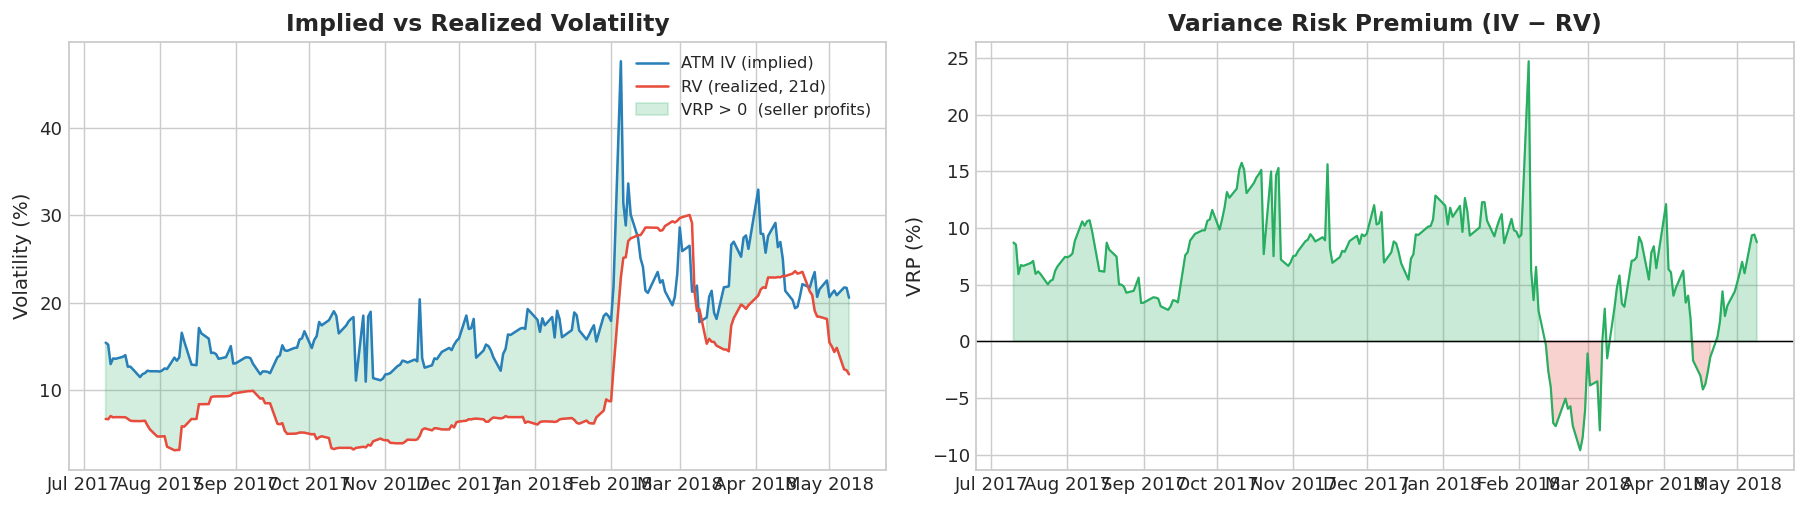

In [12]:
# ── Spot price from the dataset itself (put-call parity median per day) ────────
spot_ts = df.groupby('date')['spot'].median().sort_index()

# Add extra buffer around the sample for the rolling windows
log_ret = np.log(spot_ts / spot_ts.shift(1))

rv_past    = log_ret.rolling(RV_WINDOW).std() * np.sqrt(252)
rv_forward = log_ret.shift(-RV_WINDOW).rolling(RV_WINDOW).std() * np.sqrt(252)

# Merge into regression dataframe
reg = metrics.copy()
reg['rv_past']    = rv_past.reindex(reg.index)
reg['rv_forward'] = rv_forward.reindex(reg.index)
reg['vrp']        = reg['atm_iv'] - reg['rv_past']
reg = reg.dropna(subset=['atm_iv', 'rv_past', 'rv_forward'])

print("=== Variance Risk Premium ===")
print(f"Mean VRP (IV − RV) : {reg['vrp'].mean()*100:+.2f}%")
print(f"Std  VRP           :  {reg['vrp'].std()*100:.2f}%")
print(f"% positive (IV>RV) :  {(reg['vrp']>0).mean()*100:.1f}%")
print(f"Sample size        :  {len(reg)} days")

# ── Plot IV vs RV ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(reg.index, reg['atm_iv']*100, color='#2980b9', lw=1.4, label='ATM IV (implied)')
ax.plot(reg.index, reg['rv_past']*100, color='#e74c3c', lw=1.4, label='RV (realized, 21d)')
ax.fill_between(reg.index, reg['atm_iv']*100, reg['rv_past']*100,
                where=reg['atm_iv'] > reg['rv_past'], alpha=0.2, color='#27ae60',
                label='VRP > 0  (seller profits)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_ylabel('Volatility (%)')
ax.set_title('Implied vs Realized Volatility', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(reg.index, reg['vrp']*100, color='#27ae60', lw=1.2)
ax.axhline(0, color='black', lw=0.8)
ax.fill_between(reg.index, reg['vrp']*100, 0,
                where=reg['vrp']>0, alpha=0.25, color='#27ae60')
ax.fill_between(reg.index, reg['vrp']*100, 0,
                where=reg['vrp']<=0, alpha=0.25, color='#e74c3c')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_ylabel('VRP (%)')
ax.set_title('Variance Risk Premium (IV − RV)', fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_vrp.png', dpi=150, bbox_inches='tight')
plt.show()


## 7 · OLS regression — implementation

We implement OLS from scratch (as expected in an econometrics course):

$$\hat\beta = (X'X)^{-1}X'y, \qquad \widehat{\text{Var}}(\hat\beta) = s^2 (X'X)^{-1}, \qquad s^2 = \frac{\hat\varepsilon'\hat\varepsilon}{n-k}$$


In [13]:
def ols(y, X_df, add_const=True):
    """
    OLS estimator with full output.
    Parameters
    ----------
    y      : array-like, dependent variable
    X_df   : DataFrame or array, regressors (without constant)
    Returns dict with beta, se, t_stat, p_value, r2, adj_r2, resid
    """
    from scipy.stats import t as t_dist

    y = np.asarray(y, dtype=float)
    X = np.asarray(X_df, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    if add_const:
        X = np.column_stack([np.ones(len(X)), X])

    # Drop NaN rows
    mask = ~(np.isnan(y) | np.any(np.isnan(X), axis=1))
    y, X = y[mask], X[mask]
    n, k = X.shape

    XtX_inv = np.linalg.inv(X.T @ X)
    beta    = XtX_inv @ X.T @ y
    y_hat   = X @ beta
    resid   = y - y_hat
    s2      = (resid @ resid) / (n - k)

    se      = np.sqrt(np.diag(s2 * XtX_inv))
    t_stat  = beta / se
    p_val   = 2 * (1 - t_dist.cdf(np.abs(t_stat), df=n - k))

    ss_res = resid @ resid
    ss_tot = ((y - y.mean()) @ (y - y.mean()))
    r2     = 1 - ss_res / ss_tot
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k)

    return dict(beta=beta, se=se, t_stat=t_stat, p_val=p_val,
                r2=r2, adj_r2=adj_r2, resid=resid, n=n, k=k)


def reg_table(result, names):
    """Pretty-print regression results."""
    print(f"\n{'─'*62}")
    print(f"{'Variable':<22} {'Coef':>9} {'SE':>9} {'t':>8}  {'p':>8}")
    print(f"{'─'*62}")
    for nm, b, se, t, p in zip(names, result['beta'], result['se'],
                                result['t_stat'], result['p_val']):
        stars = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
        print(f"{nm:<22} {b:>9.4f} {se:>9.4f} {t:>8.3f}  {p:>8.4f} {stars}")
    print(f"{'─'*62}")
    print(f"{'R²':<22} {result['r2']:>9.4f}")
    print(f"{'Adj. R²':<22} {result['adj_r2']:>9.4f}")
    print(f"{'N':<22} {result['n']:>9}")
    print(f"{'─'*62}")
    print("Significance: * p<0.05  ** p<0.01  *** p<0.001")

print("✓ OLS functions defined")


✓ OLS functions defined


## 8 · Regression analysis

### Model 1 — Mincer-Zarnowitz regression (baseline)

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \varepsilon_t$$

**Interpretation**:
- If $\alpha = 0$ and $\beta_1 = 1$: IV is an **unbiased predictor** of future RV
- In practice: $\beta_1 < 1$ and $\alpha > 0$ → IV **over-estimates** RV on average (= VRP)

In [14]:
y = reg['rv_forward']

In [15]:
print("═"*62)
print("MODEL 1 — Baseline: RV_fwd ~ ATM_IV")
print("═"*62)
r1 = ols(y, reg[['atm_iv']])
reg_table(r1, ['Const', 'ATM_IV'])


══════════════════════════════════════════════════════════════
MODEL 1 — Baseline: RV_fwd ~ ATM_IV
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                    -0.0067    0.0168   -0.399    0.6900 
ATM_IV                    0.6826    0.0902    7.569    0.0000 ***
──────────────────────────────────────────────────────────────
R²                        0.2151
Adj. R²                   0.2114
N                            211
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


### Model 2 — Adding skew

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \beta_2 \cdot \text{Skew}_t + \varepsilon_t$$


In [17]:
print("\n" + "═"*62)
print("MODEL 2 — RV_fwd ~ ATM_IV + Skew")
print("═"*62)
r2 = ols(y, reg[['atm_iv', 'skew']])
reg_table(r2, ['Const', 'ATM_IV', 'Skew'])


══════════════════════════════════════════════════════════════
MODEL 2 — RV_fwd ~ ATM_IV + Skew
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0417    0.0308    1.352    0.1789 
ATM_IV                    0.4944    0.1307    3.784    0.0002 ***
Skew                      0.0189    0.3252    0.058    0.9538 
──────────────────────────────────────────────────────────────
R²                        0.1305
Adj. R²                   0.1160
N                            123
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


### Model 3 — Full model

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \beta_2 \cdot \text{Skew}_t + \beta_3 \cdot \text{Convexity}_t + \varepsilon_t$$

In [18]:
print("\n" + "═"*62)
print("MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity")
print("═"*62)
r3 = ols(y, reg[['atm_iv', 'skew', 'convexity']])
reg_table(r3, ['Const', 'ATM_IV', 'Skew', 'Convexity'])


══════════════════════════════════════════════════════════════
MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0324    0.0350    0.925    0.3570 
ATM_IV                    0.6324    0.2785    2.271    0.0250 *
Skew                     -0.1065    0.3953   -0.270    0.7880 
Convexity                 0.3204    0.5707    0.561    0.5755 
──────────────────────────────────────────────────────────────
R²                        0.1328
Adj. R²                   0.1109
N                            123
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


### Model 4

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \beta_2 \cdot \text{Convexity}_t + \varepsilon_t$$

In [19]:
print("\n" + "═"*62)
print("MODEL 4 — RV_fwd ~ ATM_IV + Convexity")
print("═"*62)
r4 = ols(y, reg[['atm_iv', 'convexity']])
reg_table(r4, ['Const', 'ATM_IV', 'Convexity'])


══════════════════════════════════════════════════════════════
MODEL 4 — RV_fwd ~ ATM_IV + Convexity
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0307    0.0343    0.894    0.3730 
ATM_IV                    0.5821    0.2060    2.825    0.0055 **
Convexity                 0.2335    0.4690    0.498    0.6195 
──────────────────────────────────────────────────────────────
R²                        0.1322
Adj. R²                   0.1178
N                            123
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [20]:
data  = reg[['atm_iv', 'convexity', 'rv_forward']].dropna()
y_m4  = data['rv_forward'].values
X_m4  = sm.add_constant(data[['atm_iv', 'convexity']].values)

res_ols = sm.OLS(y_m4, X_m4).fit()
resid = res_ols.resid

jb_stat,    jb_p          = stats.jarque_bera(resid)
dw                         = durbin_watson(resid)
bg_stat,    bg_p,   _, _  = acorr_breusch_godfrey(res_ols, nlags=21)
white_stat, white_p, _, _ = het_white(resid, X_m4)

print(f"Jarque-Bera     : stat={jb_stat:.3f}  p={jb_p:.4f}  "
      f"{'reject normality'          if jb_p    < 0.05 else 'cannot reject normality'}")
print(f"Durbin-Watson   : {dw:.4f}            "
      f"{'autocorrelation present'   if abs(dw-2)>0.5  else 'no strong autocorrelation'}")
print(f"White           : stat={white_stat:.3f}  p={white_p:.4f}  "
      f"{'reject homoscedasticity'   if white_p < 0.05 else 'cannot reject homoscedasticity'}")
print(f"Breusch-Godfrey : stat={bg_stat:.3f}  p=  {bg_p:.4f}  "
      f"{'reject no autocorrelation' if bg_p    < 0.05 else 'cannot reject no autocorrelation'}")

Jarque-Bera     : stat=23.960  p=0.0000  reject normality
Durbin-Watson   : 0.1543            autocorrelation present
White           : stat=16.631  p=0.0053  reject homoscedasticity
Breusch-Godfrey : stat=110.759  p=  0.0000  reject no autocorrelation


we introduce Newey and West robust standard error

In [21]:
res_nw  = sm.OLS(y_m4, X_m4).fit(cov_type='HAC', cov_kwds={'maxlags': 20})

# Vérification : les coefs doivent être identiques à r4
print("Coefs statsmodels :", res_ols.params)
print("Coefs from scratch:", r4['beta'])
print()
print(res_nw.summary())

Coefs statsmodels : [0.03070307 0.58211688 0.23351936]
Coefs from scratch: [0.03070307 0.58211688 0.23351936]

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.132
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     1.919
Date:                Sun, 10 May 2026   Prob (F-statistic):              0.151
Time:                        11:58:41   Log-Likelihood:                 145.48
No. Observations:                 123   AIC:                            -285.0
Df Residuals:                     120   BIC:                            -276.5
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------

## 9 · Fixed Effects & Random Effects — IV Surface Panel

### 9.1 Motivation

The IV surface contains **22 individual expiries** observed daily. A naive pooled OLS
treats all expiries identically, but options of different maturities have systematically
different IV levels due to the **term structure**: long-dated options are structurally
more expensive than short-dated ones.

Ignoring this heterogeneity biases the OLS coefficients: part of β(ATM_IV) would capture
the term structure effect rather than the true predictive relationship.

We verify this with an **F-test on entity fixed effects**:

$$F = \frac{(SSR_{\text{pooled}} - SSR_{\text{FE}}) / (N-1)}{SSR_{\text{FE}} / (NT - N - K)} \sim F(N-1,\ NT-N-K)$$

A significant F-statistic confirms that expiry-level heterogeneity exists and must be controlled.

### 9.2 Fixed Effects — within estimator

$$RV^{\text{fwd}}_{t} = \alpha_i + \beta_1\, IV_{it} + \beta_2\, \text{Conv}_{it} + \varepsilon_{it}$$

$\alpha_i$ absorbs all time-invariant characteristics of each expiry (its average IV level).
Identification comes exclusively from **within-expiry deviations over time**:

$$\tilde{y}_{it} = y_{it} - \bar{y}_i, \quad \tilde{x}_{it} = x_{it} - \bar{x}_i$$

Then OLS on the demeaned variables. The constant and all between-expiry information are removed.

### 9.3 Random Effects — GLS via quasi-demeaning

Assumes $\alpha_i \sim \mathcal{N}(0,\, \sigma^2_\alpha)$ **uncorrelated with regressors**.
Uses partial demeaning with parameter $\theta \in [0, 1]$:

$$\theta = 1 - \sqrt{\frac{\sigma^2_\varepsilon}{\sigma^2_\varepsilon + T \cdot \sigma^2_\alpha}}, \qquad \tilde{y}_{it} = y_{it} - \theta\,\bar{y}_i$$

More efficient than FE if the assumption holds, as it exploits both **within** and **between** variation.


In [23]:
def within_estimator(panel, y_col, x_cols, entity_col):
    # demean then OLS on demeaned data
    p = panel.copy()
    
    # Compute entity means
    for col in [y_col] + x_cols:
        p[col + '_mean'] = p.groupby(entity_col)[col].transform('mean')
    
    # Demean
    p[y_col + '_dm'] = p[y_col] - p[y_col + '_mean']
    for col in x_cols:
        p[col + '_dm']  = p[col]  - p[col  + '_mean']
    
    # OLS on demeaned variables (no constant — absorbed by demeaning)
    y_dm = p[y_col + '_dm'].values
    X_dm = p[[col + '_dm' for col in x_cols]].values
    
    result = ols(y_dm, X_dm, add_const=False)
    return result

In [26]:
# ── Panel par expiry individuelle ──────────────────────────────────────────────
def build_surface_panel(df, reg):
    rows = []
    for (date, exp), g in df.groupby(['date', 'exp_date']):
        T_days = (exp - date).days
        if T_days < 7:
            continue
        atm_iv = g[g['log_m'].abs() < 0.03]['iv'].mean()
        p_wing = g[(g['log_m'] > WING_LOW)  & (g['log_m'] < WING_HIGH_PUT) & (g['type']=='P')]['iv'].mean()
        c_wing = g[(g['log_m'] > WING_LOW_CALL) & (g['log_m'] < WING_HIGH)  & (g['type']=='C')]['iv'].mean()
        conv   = (p_wing + c_wing)/2 - atm_iv if not (np.isnan(p_wing) or np.isnan(c_wing)) else np.nan
        if np.isnan(atm_iv):
            continue
        rows.append({'date': date, 'expiry': exp,
                     'T_days': T_days, 'atm_iv': atm_iv, 'convexity': conv})

    panel = (pd.DataFrame(rows)
               .merge(reg[['rv_forward']].reset_index(), on='date', how='left')
               .dropna(subset=['rv_forward', 'atm_iv']))
    return panel

panel_surf = build_surface_panel(df, reg)
print(f"Panel surface : {len(panel_surf)} obs")
print(f"  Dates    : {panel_surf['date'].nunique()}")
print(f"  Expiries : {panel_surf['expiry'].nunique()}")

# ── Pooled OLS (référence) ─────────────────────────────────────────────────────
x_cols   = ['atm_iv', 'convexity']
r_pooled = ols(panel_surf['rv_forward'].values,
               panel_surf[x_cols].values)

# ── Fixed Effects par expiry ───────────────────────────────────────────────────
fe_surf = within_estimator(panel_surf, 'rv_forward', x_cols, 'expiry')

# ── F-test : effets fixes significatifs ? ─────────────────────────────────────
N  = panel_surf['expiry'].nunique()
NT = len(panel_surf)
K  = len(x_cols)
SSR_pool = np.sum(r_pooled['resid']**2)
SSR_fe   = np.sum(fe_surf['resid']**2)
F_stat   = ((SSR_pool - SSR_fe) / (N - 1)) / (SSR_fe / (NT - N - K))
F_p      = 1 - stats.f.cdf(F_stat, N - 1, NT - N - K)

# ── Random Effects + Hausman via linearmodels ──────────────────────────────────
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects

panel_idx = panel_surf.set_index(['expiry', 'date'])
y = panel_idx['rv_forward']
X = sm.add_constant(panel_idx[x_cols])

fe_lm = PanelOLS(y, X[x_cols], entity_effects=True).fit(
            cov_type='clustered', cluster_entity=True)
re_lm = RandomEffects(y, X).fit()

# ── Résultats ──────────────────────────────────────────────────────────────────
print('\n' + '═'*62)
print('POOLED OLS vs FIXED EFFECTS — surface complète (22 expiries)')
print('═'*62)
print(f"{'':22} {'Pooled OLS':>12} {'Fixed Effects':>14}")
print('─'*50)
print(f"{'β(ATM_IV)':22} {r_pooled['beta'][1]:>12.4f} {fe_surf['beta'][0]:>14.4f}")
print(f"{'β(Convexity)':22} {r_pooled['beta'][2]:>12.4f} {fe_surf['beta'][1]:>14.4f}")
print(f"{'R²':22} {r_pooled['r2']:>12.4f} {fe_surf['r2']:>14.4f}")
print('─'*50)
print(f"\nF-test effets fixes : F = {F_stat:.3f},  p = {F_p:.4f}  df = ({N-1}, {NT-N-K})")
print(f"→ {'Effets fixes significatifs → terme structure confirmée' if F_p < 0.05 else 'Non significatif'}")

print('\n' + '═'*62)
print('FIXED EFFECTS (linearmodels, SE clustered par expiry)')
print('═'*62)
print(fe_lm.summary.tables[1])

print('\n' + '═'*62)
print('RANDOM EFFECTS')
print('═'*62)
print(re_lm.summary.tables[1])

print('\n' + '═'*62)
print('HAUSMAN TEST')
print('═'*62)
from linearmodels.panel import compare
print(compare({'FE': fe_lm, 'RE': re_lm}))

Panel surface : 2259 obs
  Dates    : 211
  Expiries : 21

══════════════════════════════════════════════════════════════
POOLED OLS vs FIXED EFFECTS — surface complète (22 expiries)
══════════════════════════════════════════════════════════════
                         Pooled OLS  Fixed Effects
──────────────────────────────────────────────────
β(ATM_IV)                    1.1635         0.6768
β(Convexity)                 1.1168         1.7703
R²                           0.1471         0.0600
──────────────────────────────────────────────────

F-test effets fixes : F = 14.377,  p = 0.0000  df = (20, 2236)
→ Effets fixes significatifs → terme structure confirmée

══════════════════════════════════════════════════════════════
FIXED EFFECTS (linearmodels, SE clustered par expiry)
══════════════════════════════════════════════════════════════
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI 

### 9.4 Hausman test — choosing between FE and RE

$$H_0: \alpha_i \perp X_{it} \quad \Rightarrow \text{RE consistent and efficient}$$

$$H = (\hat\beta_{FE} - \hat\beta_{RE})^\top\,[\text{Var}(\hat\beta_{FE}) - \text{Var}(\hat\beta_{RE})]^{-1}\,(\hat\beta_{FE} - \hat\beta_{RE}) \sim \chi^2(K)$$

- **Reject** $H_0$: expiry effects correlated with regressors → only **FE** is consistent
- **Cannot reject**: RE is consistent and more efficient → **prefer RE**

In [27]:
fe_lm = PanelOLS(y, X[x_cols], entity_effects=True).fit()   # sans clustering
re_lm = RandomEffects(y, X).fit()

b_fe   = fe_lm.params.values
b_re   = re_lm.params[['atm_iv', 'convexity']].values
V_fe   = fe_lm.cov.values
V_re   = re_lm.cov.loc[['atm_iv', 'convexity'], ['atm_iv', 'convexity']].values
diff   = b_fe - b_re
H      = float(diff @ np.linalg.inv(V_fe - V_re) @ diff)
p      = 1 - stats.chi2.cdf(H, df=len(b_fe))
print(f"Hausman : stat={H:.4f}  p={p:.4f}")

Hausman : stat=75.7131  p=0.0000


# ARMA
(for a single TS -> atm_iv)

In [28]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg['atm_iv'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -2.4543
p-value: 0.1270


p>0.05 -> non stationnary

In [ ]:
# first difference is stationary (first diff is daily change in implied vol)
atm_iv_diff = reg['atm_iv'].dropna().diff().dropna()
result_diff = adfuller(atm_iv_diff)
print(f"ADF on first difference: stat={result_diff[0]:.4f}, p={result_diff[1]:.4f}")

ADF on first difference: stat=-14.8796, p=0.0000


Best ARIMA order: (p=3, d=1, q=2) with AIC=-912.19


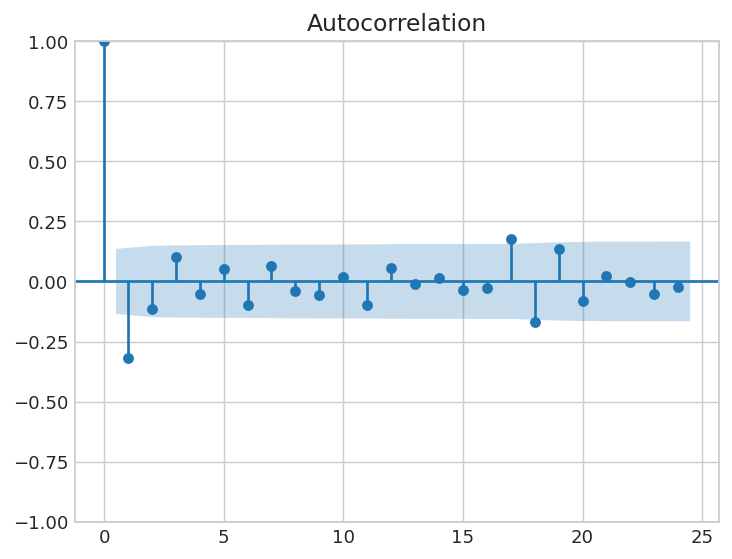

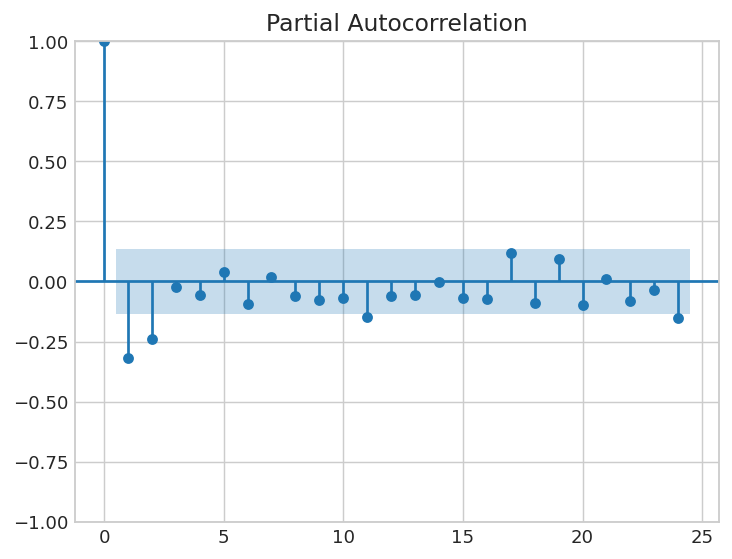

In [ ]:
# identfy p and q

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(atm_iv_diff) # gives q
plot_pacf(atm_iv_diff) # gives p

from statsmodels.tsa.arima.model import ARIMA
import itertools

best_aic = np.inf
for p,q in itertools.product(range(4), range(4)):
    try:
        model = ARIMA(reg['atm_iv'].dropna(), order=(p,1,q)).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_p, best_q = p, q
    except:
        continue
print(f"Best ARIMA order: (p={best_p}, d=1, q={best_q}) with AIC={best_aic:.2f}")

In [32]:
model = ARIMA(reg['atm_iv'].dropna(), order=(best_p,1,best_q)).fit()
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                 atm_iv   No. Observations:                  211
Model:                 ARIMA(3, 1, 2)   Log Likelihood                 462.097
Date:                Sun, 10 May 2026   AIC                           -912.195
Time:                        12:14:29   BIC                           -892.112
Sample:                             0   HQIC                          -904.076
                                - 211                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3339      0.146     -2.291      0.022      -0.620      -0.048
ar.L2          0.5857      0.149      3.920      0.000       0.293       0.878
ar.L3          0.2295      0.080      2.852      0.0

In [ ]:
# ljung-box test : check that autocorr is low
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(model.resid, lags=10)


,lb_stat,lb_pvalue
1,0.155858,0.692999
2,1.090532,0.579688
3,1.303235,0.728365
4,2.391518,0.664161
5,2.392915,0.792529
6,2.439059,0.875225
7,2.454128,0.930511
8,2.602699,0.956770
9,4.159869,0.900579
10,4.543406,0.919523


# VAR

with atm_iv, skew and convexity

In [35]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg['atm_iv'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -2.4543
p-value: 0.1270


In [36]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg['skew'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -3.2484
p-value: 0.0173


In [37]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg['convexity'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -3.3199
p-value: 0.0140


In [ ]:
# correction of stationnarity for atm_iv, skew and convexity are ok

atm_iv_diff = reg['atm_iv'].dropna().diff().dropna()
result_diff = adfuller(atm_iv_diff)
print(f"ADF on first difference: stat={result_diff[0]:.4f}, p={result_diff[1]:.4f}")

ADF on first difference: stat=-14.8796, p=0.0000


In [39]:
from statsmodels.tsa.vector_ar.var_model import VAR

# Build stationary dataframe for VAR
delta_var = pd.DataFrame({
    'datm_iv'   : reg['atm_iv'].diff(),   # first difference
    'skew'      : reg['skew'],             # ok stat
    'convexity' : reg['convexity']         # ok stat
}).dropna()

model_var = VAR(delta_var)
results = model_var.fit(maxlags=10, ic='aic')
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 10, May, 2026
Time:                     12:38:37
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -23.3308
Nobs:                     121.000    HQIC:                  -23.6189
Log likelihood:           946.793    FPE:                4.53957e-11
AIC:                     -23.8160    Det(Omega_mle):     3.83478e-11
--------------------------------------------------------------------
Results for equation datm_iv
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const                0.018099         0.017225            1.051           0.293
L1.datm_iv          -0.278164         0.176040           -1.580           0.114
L1.skew              0.049956         0.218315            0.22

In [40]:
# granger causality tests
print(results.test_causality('datm_iv', ['skew', 'convexity'], kind='f'))

# Does ATM_IV Granger-cause skew ?
print(results.test_causality('skew', ['datm_iv'], kind='f'))

# Does ATM_IV Granger-cause convexity ?
print(results.test_causality('convexity', ['datm_iv'], kind='f'))

<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ['skew', 'convexity'] do not Granger-cause datm_iv: fail to reject at 5% significance level. Test statistic: 0.900, critical value: 2.398>, p-value: 0.464>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: datm_iv does not Granger-cause skew: fail to reject at 5% significance level. Test statistic: 1.953, critical value: 3.022>, p-value: 0.143>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: datm_iv does not Granger-cause convexity: fail to reject at 5% significance level. Test statistic: 0.312, critical value: 3.022>, p-value: 0.733>


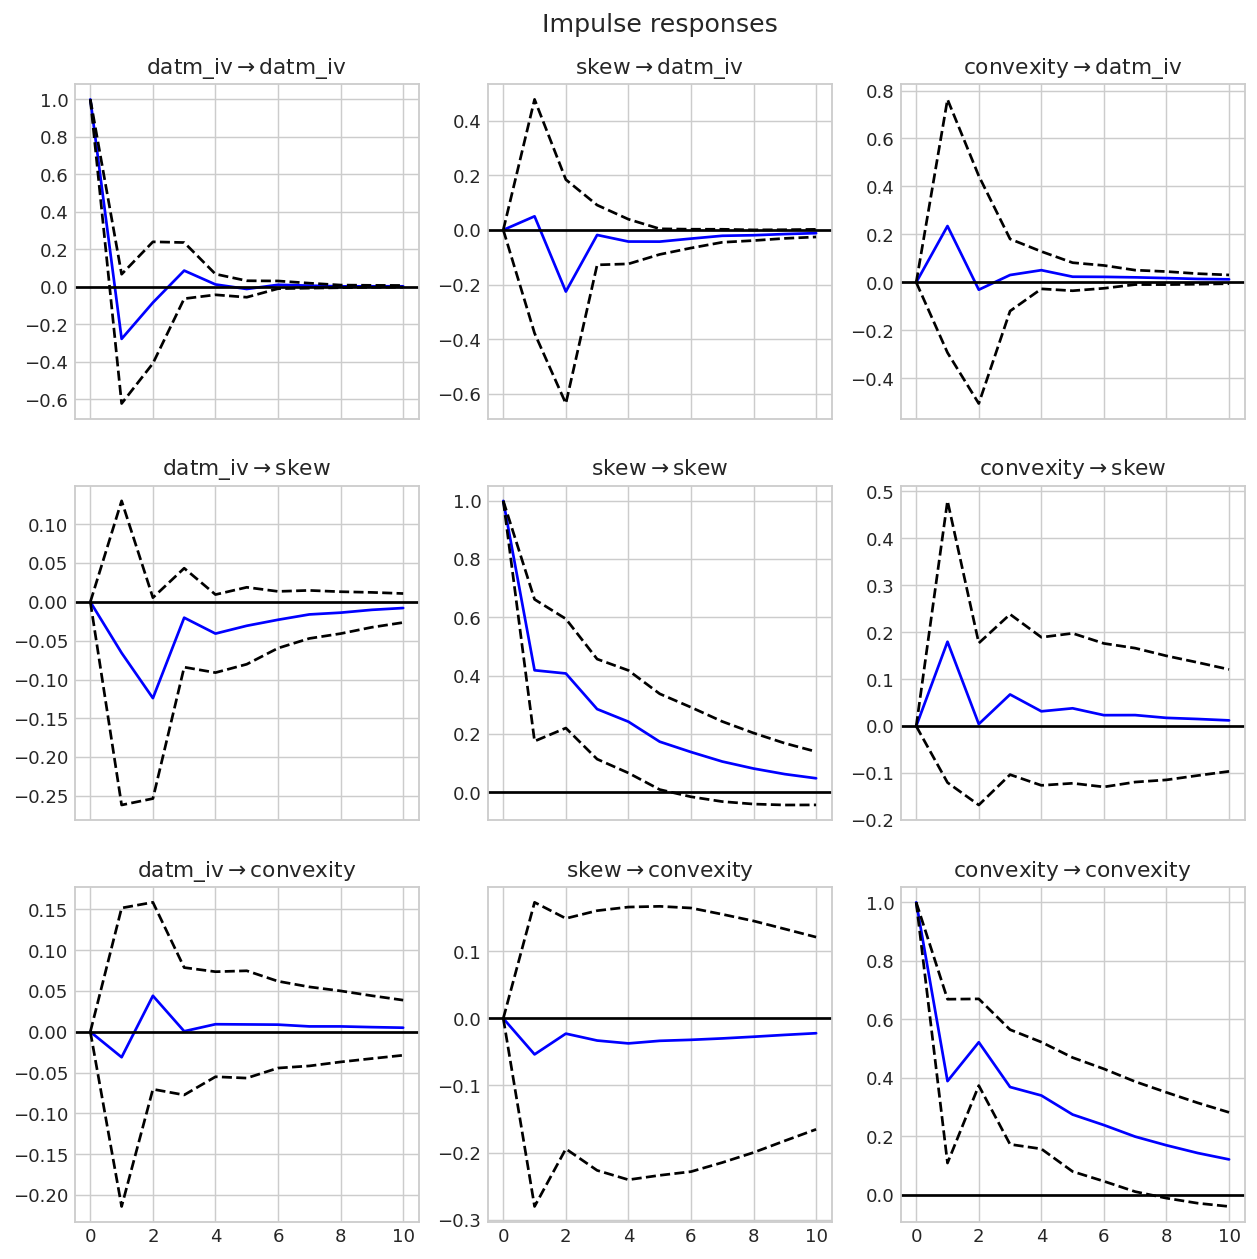

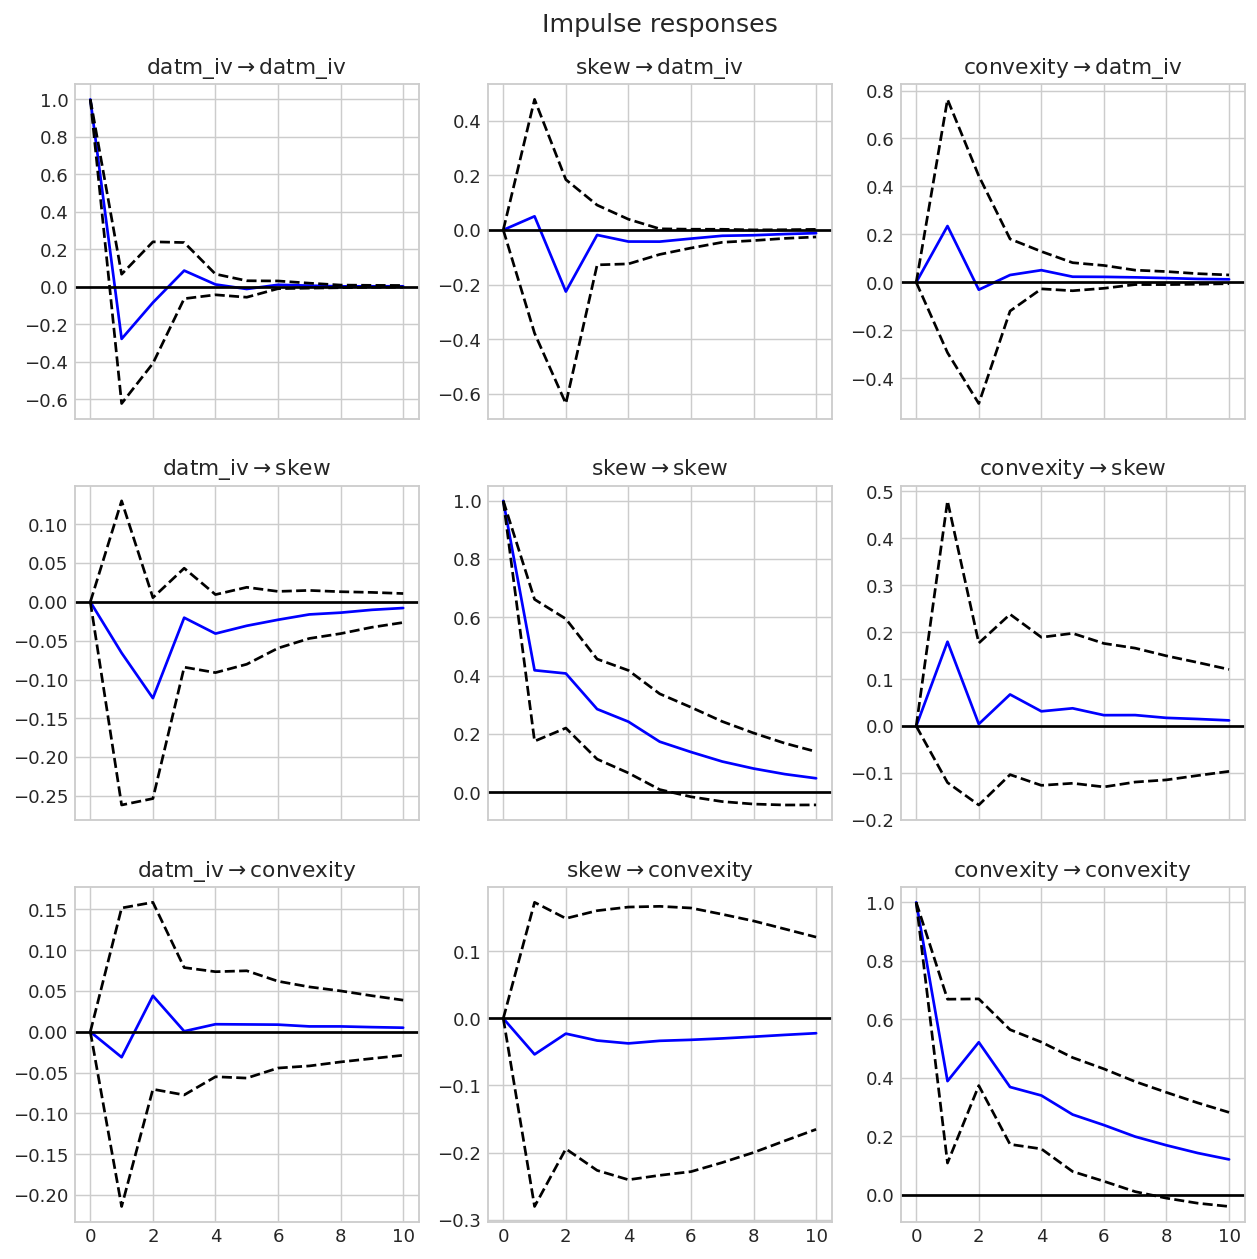

In [41]:
# impulse response functions
irf = results.irf(10)
irf.plot(orth=False)

VAR with atm_iv, skew, convexity and SP500 daily returns

In [42]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(np.log(spot_ts / spot_ts.shift(1)).dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -6.4561
p-value: 0.0000


In [43]:
from statsmodels.tsa.vector_ar.var_model import VAR

# Build stationary dataframe for VAR
delta_var = pd.DataFrame({
    'datm_iv'   : reg['atm_iv'].diff(),   # first difference
    'skew'      : reg['skew'],             # ok stat
    'convexity' : reg['convexity'],       # ok stat
    'ret'       : np.log(spot_ts / spot_ts.shift(1))         # ok stat
}).dropna()

model_var = VAR(delta_var)
results = model_var.fit(maxlags=10, ic='aic')
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 10, May, 2026
Time:                     14:28:07
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -32.8662
Nobs:                     121.000    HQIC:                  -33.3602
Log likelihood:           1387.96    FPE:                2.32075e-15
AIC:                     -33.6980    Det(Omega_mle):     1.74180e-15
--------------------------------------------------------------------
Results for equation datm_iv
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const                0.028380         0.018320            1.549           0.121
L1.datm_iv          -0.503825         0.201878           -2.496           0.013
L1.skew             -0.071456         0.222697           -0.32

In [44]:
print(results.test_causality('skew', ['ret'], kind='f'))
print(results.test_causality('datm_iv', ['ret'], kind='f'))
print(results.test_causality('convexity', ['ret'], kind='f'))

<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ret does not Granger-cause skew: fail to reject at 5% significance level. Test statistic: 1.053, critical value: 3.016>, p-value: 0.350>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ret does not Granger-cause datm_iv: fail to reject at 5% significance level. Test statistic: 2.472, critical value: 3.016>, p-value: 0.086>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ret does not Granger-cause convexity: reject at 5% significance level. Test statistic: 3.932, critical value: 3.016>, p-value: 0.020>
